# Introduction
Doing logistic regression with the clean file

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
)

In [2]:
compas = pd.read_csv("../../data/clean/compas_cleaned.csv")
compas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   sex               18316 non-null  object
 1   age               18316 non-null  int64 
 2   race              18316 non-null  object
 3   juv_fel_count     18316 non-null  int64 
 4   juv_misd_count    18316 non-null  int64 
 5   juv_other_count   18316 non-null  int64 
 6   priors_count      18316 non-null  int64 
 7   c_charge_degree   17449 non-null  object
 8   c_charge_desc     17435 non-null  object
 9   is_recid          18316 non-null  int64 
 10  is_violent_recid  18316 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 1.5+ MB


In [3]:
print(compas.shape)
compas = compas.dropna(subset=["c_charge_degree", "c_charge_desc"])
print(compas.shape)


(18316, 11)
(17435, 11)


In [4]:
compas['is_recid'].value_counts()

is_recid
 0    9063
 1    8371
-1       1
Name: count, dtype: int64

In [5]:
# Variables
num_cols = ["age", "juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count"]
cat_cols = ["c_charge_degree", "sex", "race"]  

In [6]:
df = compas[num_cols + cat_cols + ["is_recid"]].copy()
df = df[df["is_recid"] != -1].copy()

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17434 entries, 0 to 18315
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              17434 non-null  int64 
 1   juv_fel_count    17434 non-null  int64 
 2   juv_misd_count   17434 non-null  int64 
 3   juv_other_count  17434 non-null  int64 
 4   priors_count     17434 non-null  int64 
 5   c_charge_degree  17434 non-null  object
 6   sex              17434 non-null  object
 7   race             17434 non-null  object
 8   is_recid         17434 non-null  int64 
dtypes: int64(6), object(3)
memory usage: 1.3+ MB


In [8]:
# Définir X et y
X = df[num_cols + cat_cols]
y = df["is_recid"].astype(int)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Préprocesseur : numériques -> passthrough, catégorielles -> OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

In [9]:
# Modèle : Régression logistique
log_reg = LogisticRegression(max_iter=2000, solver="liblinear", class_weight="balanced")


In [10]:
# Pipeline complet
pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", log_reg)
])


In [11]:
# Entraînement
pipe.fit(X_train, y_train)


,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
# Évaluation
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

In [13]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

Accuracy: 0.6622
ROC AUC: 0.718

Confusion matrix:
 [[1778  941]
 [ 826 1686]]

Classification report:
               precision    recall  f1-score   support

           0     0.6828    0.6539    0.6680      2719
           1     0.6418    0.6712    0.6562      2512

    accuracy                         0.6622      5231
   macro avg     0.6623    0.6625    0.6621      5231
weighted avg     0.6631    0.6622    0.6623      5231



In [14]:
# Get feature names after preprocessing
num_features = num_cols
cat_features = list(
    pipe.named_steps["prep"].named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)
all_features = num_features + cat_features

# Extract coefficients from the logistic regression
coefs = pipe.named_steps["clf"].coef_.ravel()

# Create a dataframe for readability
coef_df = pd.DataFrame({
    "feature": all_features,
    "coefficient": coefs,
    "abs_value": abs(coefs)
}).sort_values(by="abs_value", ascending=False)

print(coef_df)


                  feature  coefficient  abs_value
15  c_charge_degree_(NI0)     1.693487   1.693487
9    c_charge_degree_(F5)    -1.648452   1.648452
5   c_charge_degree_(CO3)     1.569220   1.569220
10   c_charge_degree_(F6)    -1.399618   1.399618
6    c_charge_degree_(F1)    -0.658264   0.658264
8    c_charge_degree_(F3)     0.282338   0.282338
14  c_charge_degree_(MO3)     0.272506   0.272506
18               sex_Male     0.264360   0.264360
19  race_African-American     0.235427   0.235427
12   c_charge_degree_(M1)     0.203768   0.203768
21         race_Caucasian     0.198596   0.198596
3         juv_other_count     0.197290   0.197290
13   c_charge_degree_(M2)     0.184688   0.184688
20             race_Asian    -0.154082   0.154082
11   c_charge_degree_(F7)    -0.145127   0.145127
4            priors_count     0.117372   0.117372
16  c_charge_degree_(TCX)    -0.104352   0.104352
22          race_Hispanic    -0.094914   0.094914
24             race_Other     0.055173   0.055173


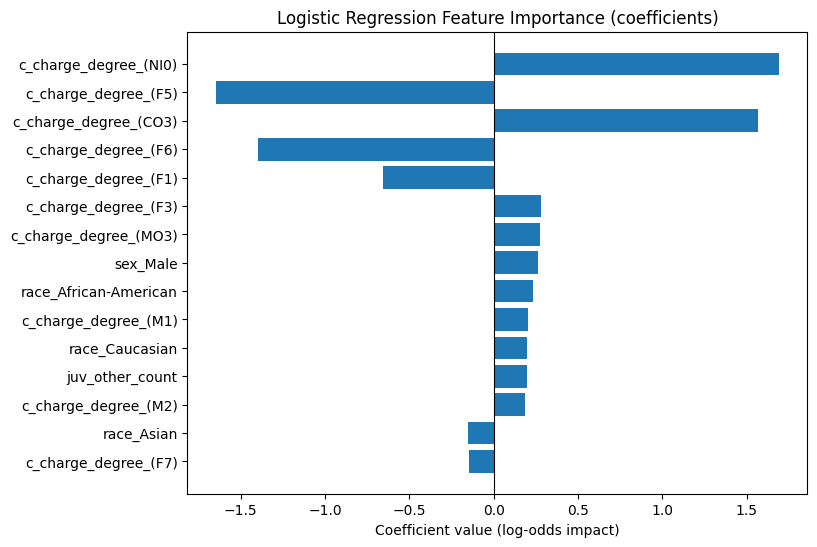

In [15]:
import matplotlib.pyplot as plt

top = coef_df.head(15)  # top 15 features

plt.figure(figsize=(8,6))
plt.barh(top["feature"], top["coefficient"])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Feature Importance (coefficients)")
plt.xlabel("Coefficient value (log-odds impact)")
plt.gca().invert_yaxis()
plt.show()


In [16]:
# On part de coef_df qui contient toutes les modalités après OneHotEncoder
# et leurs coefficients

# Créer une colonne "base_feature"
coef_df["base_feature"] = coef_df["feature"].apply(
    lambda x: x.split("_")[0] if "_" in x else x
)

# Agréger par feature de base avec somme des abs(coef)
coef_base = (
    coef_df.groupby("base_feature", as_index=False)["abs_value"]
           .sum()
           .sort_values("abs_value", ascending=False)
)

print(coef_base)


  base_feature  abs_value
1            c   8.187973
4         race   0.754352
5          sex   0.304679
2          juv   0.279495
3       priors   0.117372
0          age   0.039423


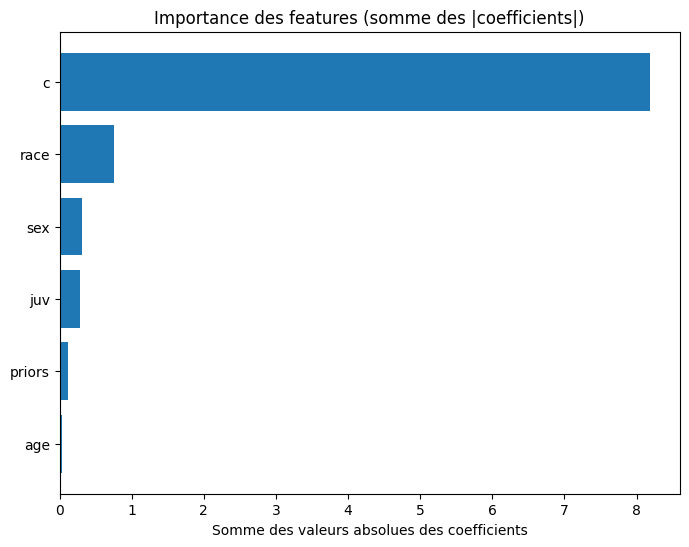

In [17]:
plt.figure(figsize=(8,6))
plt.barh(coef_base["base_feature"], coef_base["abs_value"])
plt.gca().invert_yaxis()
plt.title("Importance des features (somme des |coefficients|)")
plt.xlabel("Somme des valeurs absolues des coefficients")
plt.show()


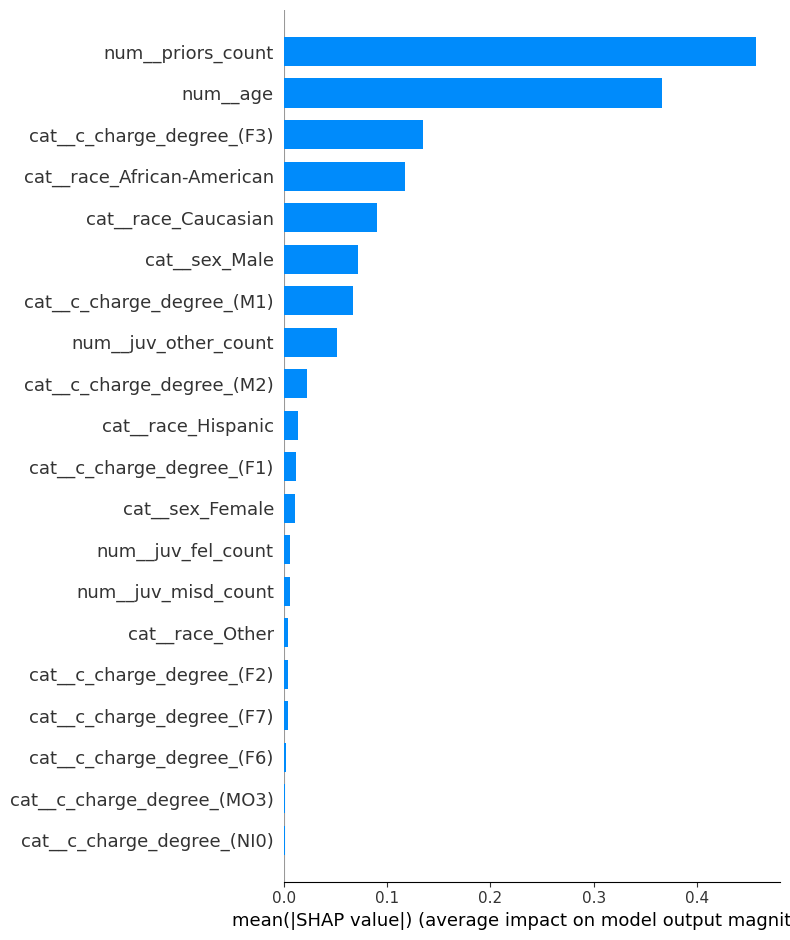

In [21]:
import shap
import numpy as np

# 1) Background (petit échantillon) puis transformation
X_bg = X_train.sample(200, random_state=42)
X_bg_enc = pipe.named_steps["prep"].transform(X_bg)

# 2) Test transformé
X_test_enc = pipe.named_steps["prep"].transform(X_test)

# 3) Explainer linéaire sur le modèle logistique
explainer = shap.LinearExplainer(pipe.named_steps["clf"], X_bg_enc)

# 4) SHAP values sur le test encodé
shap_values = explainer(X_test_enc)

# 5) Noms de features encodées (numériques + one-hot)
feature_names_enc = list(pipe.named_steps["prep"].get_feature_names_out())

# 6) Résumé global
shap.summary_plot(shap_values, feature_names=feature_names_enc, plot_type="bar")
# (et la version nuage)
# shap.summary_plot(shap_values, feature_names=feature_names_enc)


/tmp/ipykernel_39304/2962802853.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, feature_names=feature_names_enc)


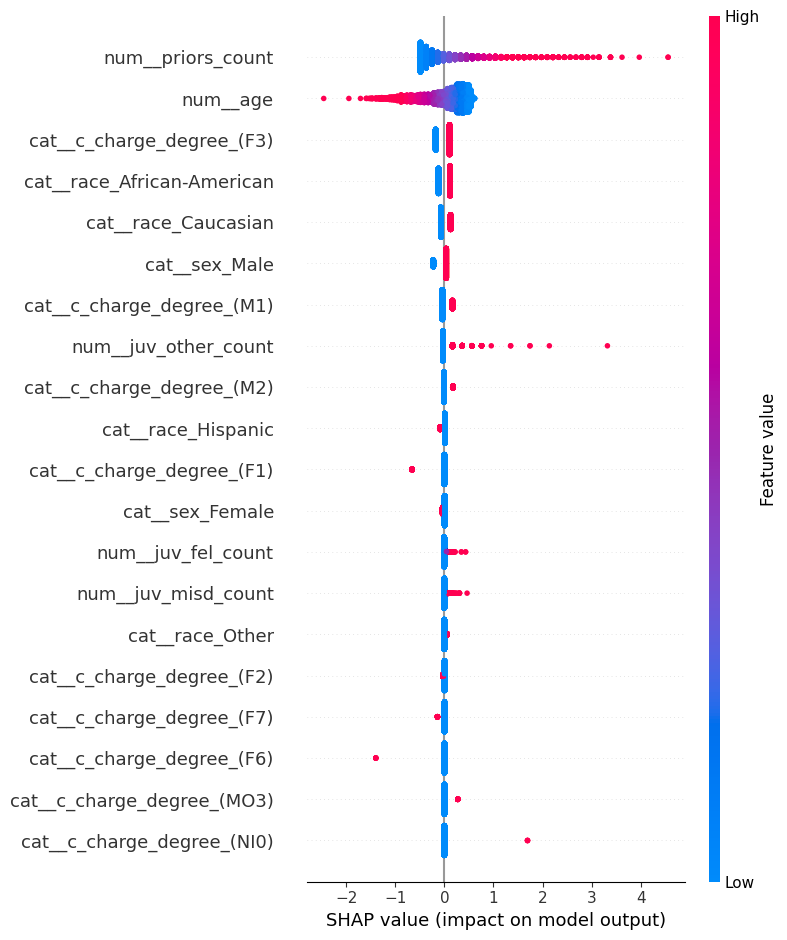

In [23]:
shap.summary_plot(shap_values, feature_names=feature_names_enc)

  base_feature  importance
3       priors    0.457182
0          age    0.366134
1            c    0.251166
4         race    0.226928
5          sex    0.083040
2          juv    0.064444


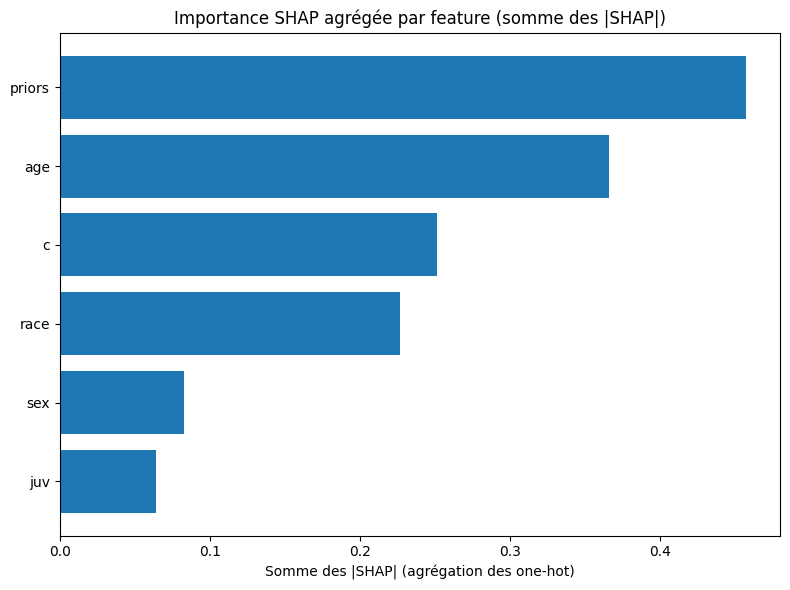

In [25]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Importance par colonne encodée = |SHAP| moyen par colonne
mean_abs_enc = np.abs(shap_values.values).mean(axis=0)
imp_enc = pd.DataFrame({
    "encoded_feature": feature_names_enc,
    "importance": mean_abs_enc
})

# 2) Extraire le "base_feature" depuis les noms de colonnes du ColumnTransformer
#    - get_feature_names_out() renvoie typiquement "num__age", "cat__race_African-American", ...
def to_base_feature(name: str) -> str:
    # enlever le préfixe transformeur "num__" ou "cat__"
    if "__" in name:
        name = name.split("__", 1)[1]
    # pour les catégorielles one-hot: "race_African-American" -> "race"
    # pour les numériques: "age" reste "age"
    return name.split("_", 1)[0]

imp_enc["base_feature"] = imp_enc["encoded_feature"].apply(to_base_feature)

# 3) Agréger par feature de base avec la **somme** des importances (somme des |SHAP|)
imp_base = (
    imp_enc.groupby("base_feature", as_index=False)["importance"]
           .sum()
           .sort_values("importance", ascending=False)
)

print(imp_base)

# 4) Barplot (top 15)
top = imp_base.head(15)
plt.figure(figsize=(8, 6))
plt.barh(top["base_feature"], top["importance"])
plt.gca().invert_yaxis()
plt.title("Importance SHAP agrégée par feature (somme des |SHAP|)")
plt.xlabel("Somme des |SHAP| (agrégation des one-hot)")
plt.tight_layout()
plt.show()


# Random Forest

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import shap
import matplotlib.pyplot as plt
import numpy as np

In [27]:
# 3) Colonnes
num_cols = ["age", "juv_fel_count", "juv_misd_count", "juv_other_count", "priors_count"]
cat_cols = ["c_charge_degree", "sex", "race"]
target = "is_recid"

In [28]:
# 5) X et y
X = df[num_cols + cat_cols]
y = df[target].astype(int)


In [29]:
# 6) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [30]:
# 7) Préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

In [31]:
# 8) Modèle Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [32]:
# 9) Pipeline
pipe_rf = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", rf)
])


In [33]:
# 10) Entraînement
pipe_rf.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
# 11) Évaluation
y_pred = pipe_rf.predict(X_test)
y_proba = pipe_rf.predict_proba(X_test)[:,1]

In [35]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

Accuracy: 0.7507
ROC AUC: 0.8348

Confusion matrix:
 [[1998  721]
 [ 583 1929]]

Classification report:
               precision    recall  f1-score   support

           0     0.7741    0.7348    0.7540      2719
           1     0.7279    0.7679    0.7474      2512

    accuracy                         0.7507      5231
   macro avg     0.7510    0.7514    0.7507      5231
weighted avg     0.7519    0.7507    0.7508      5231



In [36]:
# 12) SHAP TreeExplainer
# --- on doit transformer X_train avec le preprocess
X_train_enc = pipe_rf.named_steps["prep"].transform(X_train)
X_test_enc = pipe_rf.named_steps["prep"].transform(X_test)
feature_names_enc = list(pipe_rf.named_steps["prep"].get_feature_names_out())

In [ ]:
explainer = shap.TreeExplainer(pipe_rf.named_steps["clf"])
shap_values = explainer.shap_values(X_test_enc)

In [ ]:
# 13) Importance globale (bar plot)
shap.summary_plot(shap_values[1], X_test_enc, feature_names=feature_names_enc, plot_type="bar")

In [ ]:
# 14) Version nuage (impact de chaque variable par individu)
shap.summary_plot(shap_values[1], X_test_enc, feature_names=feature_names_enc)